In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch

from MLP_template import MLP, load_data

# ensure output directories exist
os.makedirs('images/MLP/curves', exist_ok=True)
os.makedirs('images/MLP/sample', exist_ok=True)
os.makedirs('images/MLP/weights', exist_ok=True)
os.makedirs('images/MLP/errors', exist_ok=True)

COLOR_PRIMARY = '#4C72B0'
COLOR_SECONDARY = '#DD8452'
COLOR_ERROR = '#C44E52'
COLOR_TEXT = '#333333'

# custom colormaps
CMAP_DIVERGING = LinearSegmentedColormap.from_list('custom_div', [COLOR_SECONDARY, 'white', COLOR_PRIMARY])
CMAP_SEQUENTIAL = LinearSegmentedColormap.from_list('custom_seq', ['white', COLOR_PRIMARY])

# font and style 
plt.rcParams.update({
    'text.color': COLOR_TEXT,
    'axes.labelcolor': COLOR_TEXT,
    'xtick.color': COLOR_TEXT,
    'ytick.color': COLOR_TEXT,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False 
})

In [2]:
from MLP_template import main

print("Running MLP_template's main() function")
model, loss_history, train_acc_history, test_acc_history, test_loader = main()

input_size = 28 * 28
num_epochs = len(loss_history)

Running MLP_template's main() function
The number of training data: 60000
The number of testing data: 10000
Epoch 1/30, Loss: 0.6152, Train Acc: 0.9098, Test Acc: 0.9112
Epoch 2/30, Loss: 0.2521, Train Acc: 0.9377, Test Acc: 0.9373
Epoch 3/30, Loss: 0.1918, Train Acc: 0.9499, Test Acc: 0.9480
Epoch 4/30, Loss: 0.1529, Train Acc: 0.9633, Test Acc: 0.9607
Epoch 5/30, Loss: 0.1299, Train Acc: 0.9663, Test Acc: 0.9621
Epoch 6/30, Loss: 0.1130, Train Acc: 0.9690, Test Acc: 0.9619
Epoch 7/30, Loss: 0.1008, Train Acc: 0.9724, Test Acc: 0.9663
Epoch 8/30, Loss: 0.0898, Train Acc: 0.9780, Test Acc: 0.9697
Epoch 9/30, Loss: 0.0816, Train Acc: 0.9807, Test Acc: 0.9719
Epoch 10/30, Loss: 0.0742, Train Acc: 0.9817, Test Acc: 0.9733
Epoch 11/30, Loss: 0.0680, Train Acc: 0.9839, Test Acc: 0.9737
Epoch 12/30, Loss: 0.0632, Train Acc: 0.9821, Test Acc: 0.9717
Epoch 13/30, Loss: 0.0585, Train Acc: 0.9827, Test Acc: 0.9715
Epoch 14/30, Loss: 0.0538, Train Acc: 0.9869, Test Acc: 0.9739
Epoch 15/30, Loss: 

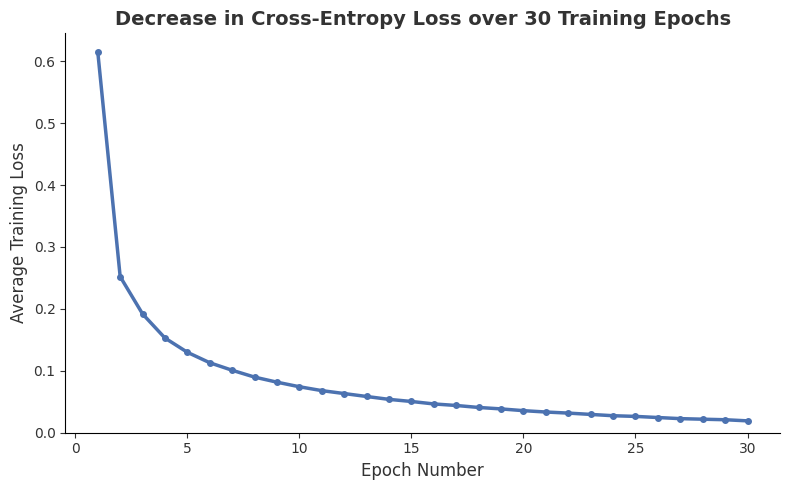

In [3]:
# 1. Training Loss Curve (Epochs vs. Loss)
plt.figure(figsize=(8, 5))
epochs = range(1, num_epochs + 1)
plt.plot(epochs, loss_history, color=COLOR_PRIMARY, linewidth=2.5, marker='o', markersize=4)

plt.title('Decrease in Cross-Entropy Loss over 30 Training Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch Number', fontsize=12)
plt.ylabel('Average Training Loss', fontsize=12)
plt.ylim(bottom=0) 

plt.tight_layout()
plt.savefig('images/MLP/curves/training_loss_curve.png', dpi=300)
plt.show()

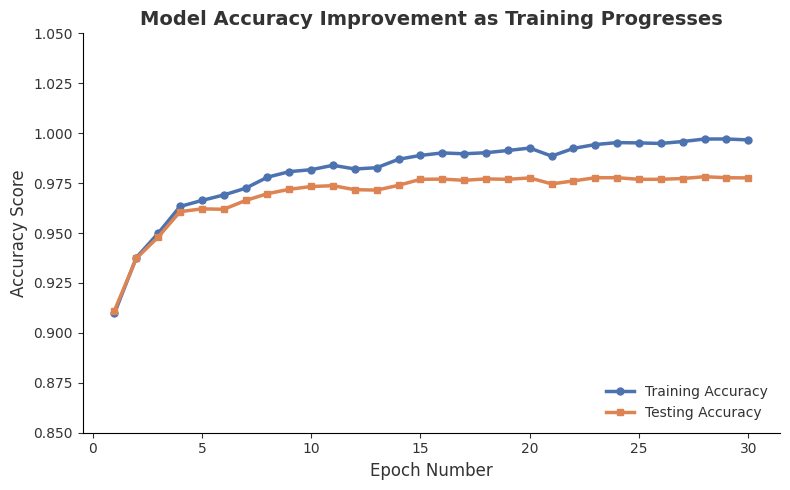

In [4]:
# 2. Accuracy Curve (Training/Testing Accuracy vs Epochs)
plt.figure(figsize=(8, 5))

tr_acc = [acc[1] for acc in train_acc_history]
te_acc = [acc[1] for acc in test_acc_history]
epochs_indices = [acc[0] for acc in train_acc_history]

plt.plot(epochs_indices, tr_acc, marker='o', color=COLOR_PRIMARY, label='Training Accuracy', linewidth=2.5, markersize=5)
plt.plot(epochs_indices, te_acc, marker='s', color=COLOR_SECONDARY, label='Testing Accuracy', linewidth=2.5, markersize=5)

plt.title('Model Accuracy Improvement as Training Progresses', fontsize=14, fontweight='bold')
plt.xlabel('Epoch Number', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0.85, 1.05) 
plt.legend(loc='lower right', frameon=False) 

plt.tight_layout()
plt.savefig('images/MLP/curves/accuracy_curve.png', dpi=300)
plt.show()

In [5]:
# 2.5 Define "Reference Images" to track operations on the SAME inputs consistently
# This ensures that our report figures will analyze exactly what happens to the same hand-picked digits sequentially.
reference_digits_to_find = [0, 2, 4, 7, 9]
reference_images = []
reference_labels = []

for digit in reference_digits_to_find:
    # Find the first occurrence of this digit in the test set
    idx = (test_loader.dataset.targets == digit).nonzero(as_tuple=True)[0][0].item()
    img = test_loader.dataset.data[idx].numpy() / 255.0 # normalize to [0,1] for display purposes natively if needed
    
    # Actually grab the normalized tensor directly from loader pipeline to be mathematically identical
    img_tensor = test_loader.dataset[idx][0].squeeze().numpy() 
    
    reference_images.append(img_tensor)
    reference_labels.append(digit)

print("Selected global reference images for classes:", reference_labels)

Selected global reference images for classes: [0, 2, 4, 7, 9]


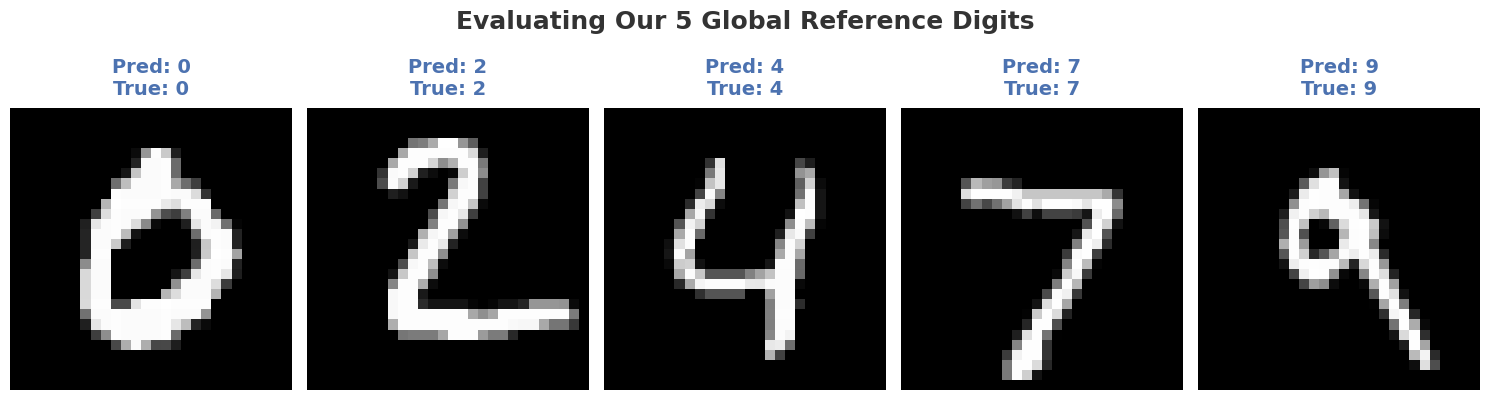

In [6]:
# 3. Sample Predictions (Visualizations using our Reference Digits [0, 2, 4, 7, 9])
# Instead of a random batch, we explicitly predict on our carefully chosen global reference images.

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle('Evaluating Our 5 Global Reference Digits', fontsize=18, fontweight='bold', y=1.05)

for i in range(5):
    img = reference_images[i]
    true_label = reference_labels[i]
    
    # Flatten and run the forward pass
    x_input = img.reshape(1, 784)
    pred_probs = model.forward(x_input)
    pred_label = np.argmax(pred_probs, axis=1)[0]

    # Use a divergent colormap or gray to match styles
    # We display the normalized image
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    
    # Text Color flips to Red if prediction is wrong!
    label_color = COLOR_PRIMARY if true_label == pred_label else COLOR_ERROR
    
    title_text = f"Pred: {pred_label}\nTrue: {true_label}"
    axes[i].set_title(title_text, color=label_color, fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('images/MLP/sample/sample_reference_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

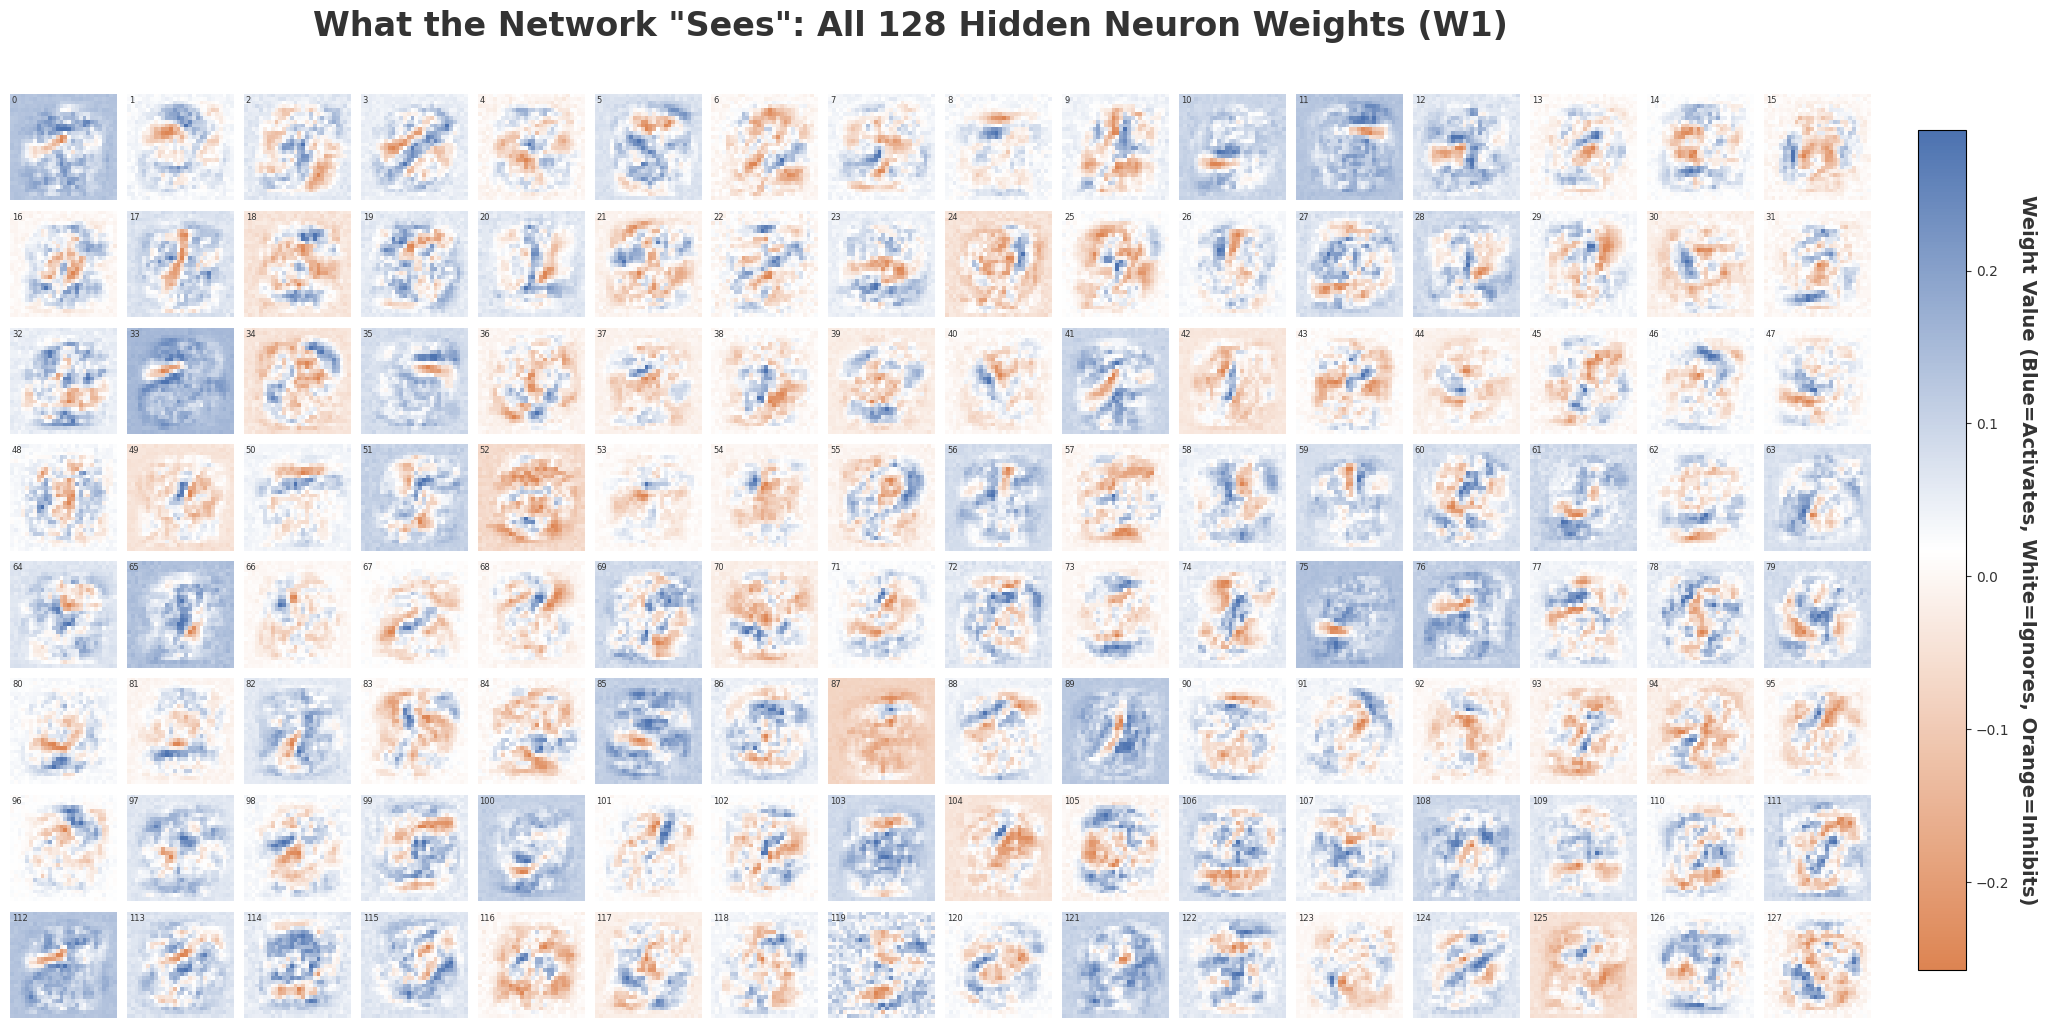

In [7]:
# 4. Feature Visualization: All 128 Hidden Neurons
# The first layer 'w1' is of size (784, 128).
# Each of the 128 hidden neurons essentially looks for a specific "pattern" in the 784 pixels.
# We reshape its weights back into a 28x28 grid to see what those neurons "learned" to look for.
# By plotting them in an 8x16 grid, this perfectly matches the visual layout of our Activation (A1) plots!

fig, axes = plt.subplots(8, 16, figsize=(24, 12))
fig.suptitle('What the Network "Sees": All 128 Hidden Neuron Weights (W1)', fontsize=24, fontweight='bold', y=0.95)

w1_learned = model.w1  # Shape: (784, 128)

for row in range(8):
    for col in range(16):
        neuron_idx = row * 16 + col
        # Reshape the 784 weight array into the original image shape of 28x28
        weight_img = w1_learned[:, neuron_idx].reshape(28, 28)
        
        ax = axes[row, col]
        
        # We use our custom divergent colormap mapped to our primary palette
        # Primary Blue -> Positive weight (Activates), Error Red -> Negative weight (Inhibits)
        im = ax.imshow(weight_img, cmap=CMAP_DIVERGING, interpolation='nearest')
        ax.axis('off')
        
        # Optionally add tiny text for neuron index if you want to look it up, 
        # but the absolute grid position matches A1 perfectly.
        ax.text(0, 0, str(neuron_idx), color=COLOR_TEXT, fontsize=6, verticalalignment='top')

# Add a colorbar to explain the meaning of the colors
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Weight Value (Blue=Activates, White=Ignores, Orange=Inhibits)', rotation=270, labelpad=20, fontsize=14, fontweight='bold')

plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.savefig('images/MLP/weights/all_128_learned_weights.png', dpi=300, bbox_inches='tight')
plt.show()

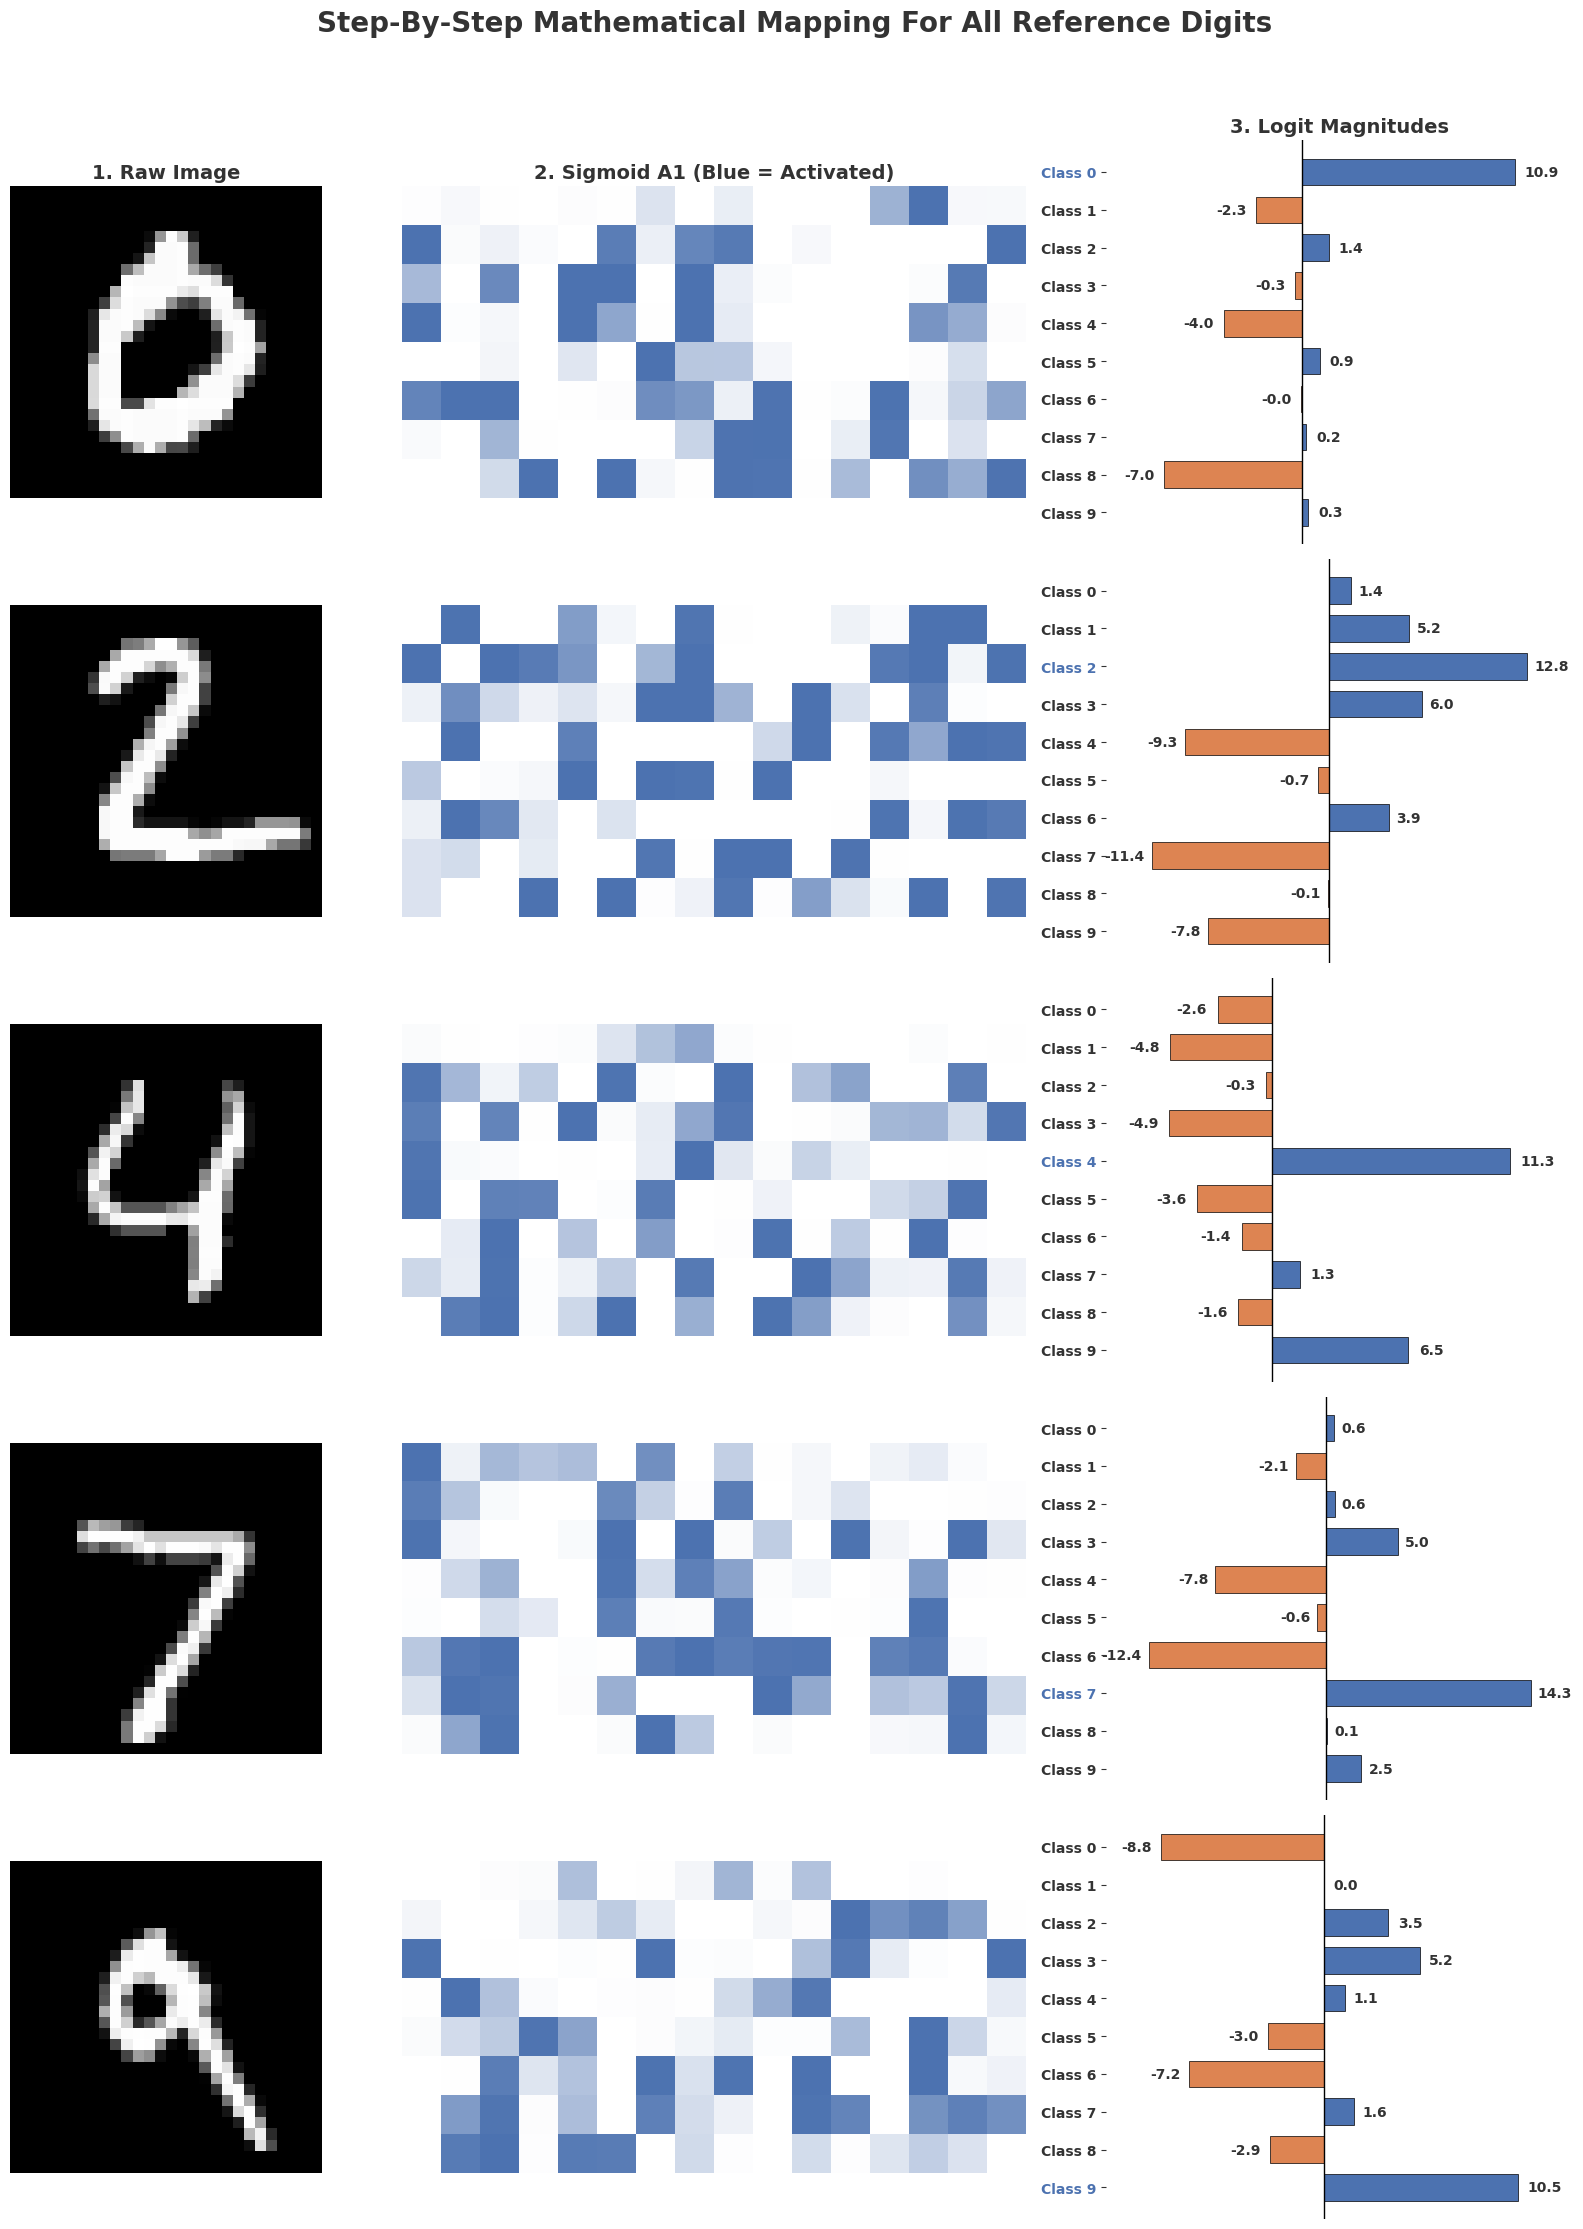

In [8]:
# 5. Explaining the Forward Propagation (Step-by-step activations)
# Taking our 5 Global Reference Images and passing them manually to see intermediate outputs completely!
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 5 * len(reference_labels)))
fig.suptitle('Step-By-Step Mathematical Mapping For All Reference Digits', fontsize=20, fontweight='bold', y=0.92)

# Use GridSpec to make the middle column wider since Sigmoid A1 is 8x16
gs = fig.add_gridspec(len(reference_labels), 3, width_ratios=[1, 2, 1.5])

for row, digit in enumerate(reference_labels):
    sample_img = reference_images[row]
    x_test_single = sample_img.reshape(1, 784)
    # Manual forward pass step-by-step to expose hidden representation explicitly!
    z1_test = np.dot(x_test_single, model.w1) + model.b1
    manual_a1 = 1 / (1 + np.exp(-z1_test))  # manual sigmoid!
    z2_test = np.dot(manual_a1, model.w2) + model.b2
    
    # 1. Raw Image
    ax1 = fig.add_subplot(gs[row, 0])
    ax1.imshow(sample_img, cmap='gray')
    if row == 0:
        ax1.set_title('1. Raw Image', fontsize=14, fontweight='bold', color=COLOR_TEXT)
    ax1.axis('off')

    # 2. Hidden Layer Activation (A1)
    # Did the hidden neurons "light up" (primary blue) or stay dim (white) for this digit?
    ax2 = fig.add_subplot(gs[row, 1])
    ax2.imshow(manual_a1.reshape(8, 16), cmap=CMAP_SEQUENTIAL, interpolation='nearest')
    if row == 0:
        ax2.set_title('2. Sigmoid A1 (Blue = Activated)', fontsize=14, fontweight='bold', color=COLOR_TEXT)
    ax2.axis('off')

    # 3. Raw Logits (Z2 Vector before Softmax)
    ax3 = fig.add_subplot(gs[row, 2])
    logits = z2_test.flatten()
    classes = np.arange(10)
    
    colors = [COLOR_PRIMARY if val > 0 else COLOR_SECONDARY for val in logits]
    bars = ax3.barh(classes, logits, color=colors, height=0.7, edgecolor='black', linewidth=0.5)
    
    ax3.axvline(0, color='black', linewidth=1)
    ax3.set_yticks(classes)
    ax3.set_yticklabels([f"Class {i}" for i in classes], fontweight='bold')
    
    # Put class 0 at the top
    ax3.invert_yaxis()
    
    # Bold out the true label
    ax3.get_yticklabels()[digit].set_color(COLOR_PRIMARY)
    
    if row == 0:
        ax3.set_title('3. Logit Magnitudes', fontsize=14, fontweight='bold', color=COLOR_TEXT)
        
    for bar, val in zip(bars, logits):
        if val >= 0:
            ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
                     va='center', ha='left', fontsize=10, fontweight='bold')
        else:
            ax3.text(val - 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
                     va='center', ha='right', fontsize=10, fontweight='bold')

    # Keep a bit of padding for exact value text correctly spanning the 0 center
    ax3.set_xlim(min(logits) - 3, max(logits) + 3)
    
    # Remove borders and x-axis ticks to make it clean
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.spines['bottom'].set_visible(False)
    ax3.spines['left'].set_visible(False)
    ax3.set_xticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.savefig('images/MLP/sample/forward_propagation_reference_steps.png', dpi=300, bbox_inches='tight')
plt.show()

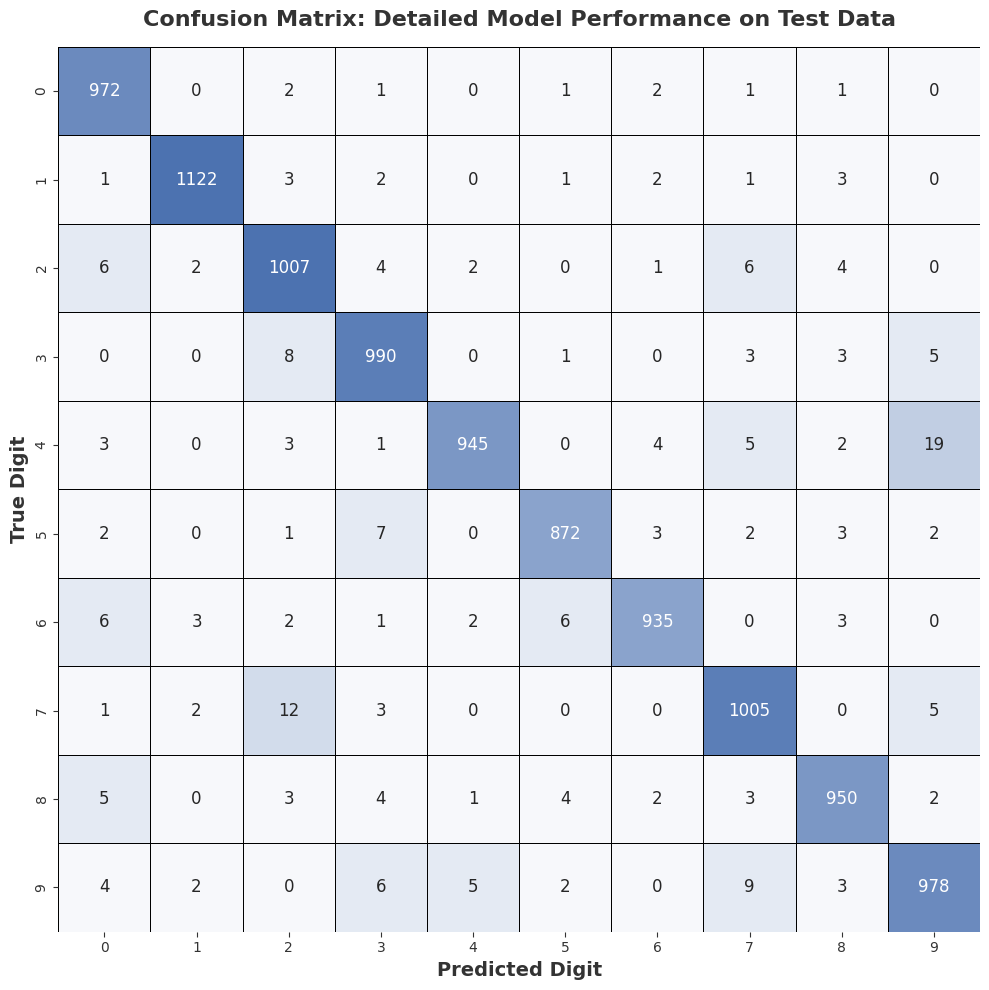

In [9]:
# 6. Confusion Matrix for Detailed Performance Evaluation
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd

# Collect all predictions and true labels from test_loader to build the confusion matrix
all_preds = []
all_trues = []
for inputs, labels in test_loader:
    x_batch = inputs.view(-1, input_size).numpy()
    preds = model.forward(x_batch)
    pred_labels = np.argmax(preds, axis=1)
    all_preds.extend(pred_labels)
    all_trues.extend(labels.numpy())

cm = confusion_matrix(all_trues, all_preds)

# 9 natural groups: 
# Bottom 4 groups divide the 90 misclassifications
# Top 5 groups strictly isolate the 10 highest values (the correct diagonal), putting exactly 2 in each group.
flat_cm = cm.flatten()
sorted_vals = np.sort(flat_cm)

bot_90 = sorted_vals[:-10]
top_10 = sorted_vals[-10:]

bot_max = max(1.0, bot_90[-1])

# 4 bounds for the bottom 90 items to create 4 bins for the low-end
bot_bounds = [-0.5, bot_max * 0.25, bot_max * 0.50, bot_max * 0.75]

# Bounds separating the top 10 items into 5 groups of 2 (Midpoint calculations)
sep0 = (bot_90[-1] + top_10[0]) / 2.0
sep1 = (top_10[1] + top_10[2]) / 2.0
sep2 = (top_10[3] + top_10[4]) / 2.0
sep3 = (top_10[5] + top_10[6]) / 2.0
sep4 = (top_10[7] + top_10[8]) / 2.0
top_bound = top_10[-1] + 0.5

raw_bounds = bot_bounds + [sep0, sep1, sep2, sep3, sep4, top_bound]

# Ensure bounds strictly increase (in case of identical consecutive values or many 0s)
bounds = [raw_bounds[0]]
for b in raw_bounds[1:]:
    bounds.append(max(b, bounds[-1] + 0.1))

# Generate colors with a clear gap to separate low magnitudes from high magnitudes visually
# Low 4 groups use the 5% to 35% intensity range
low_colors = CMAP_SEQUENTIAL(np.linspace(0.05, 0.35, 4))
# High 5 groups use the 65% to 100% intensity range (creating a 30% visual gap)
high_colors = CMAP_SEQUENTIAL(np.linspace(0.65, 1.0, 5))

cmap_colors = np.vstack((low_colors, high_colors))

# Ensure exactly 9 colors for exactly 9 bins (10 bounds)
num_bins = len(bounds) - 1
cmap_colors = cmap_colors[:num_bins]

custom_cmap = mcolors.ListedColormap(cmap_colors)
norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)

plt.figure(figsize=(10, 10))

# Apply custom norm and colormap with explicit bins
sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, norm=norm, cbar=False, 
            annot_kws={'size': 12}, 
            linecolor='black', linewidths=0.5)

plt.title('Confusion Matrix: Detailed Model Performance on Test Data', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Digit', fontsize=14, fontweight='bold')
plt.ylabel('True Digit', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('images/MLP/errors/confusion_matrix.png', dpi=300)
plt.show()

In [10]:
# 7. Error Analysis: Visualizing All Misclassified Examples per Digit with Forward Pass
import math
import os
import matplotlib.gridspec as gridspec

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)

# Iterate over every single digit class (0-9)
for true_l in range(10):
    # Create directory for the true digit
    os.makedirs(f'images/MLP/errors/{true_l}', exist_ok=True)
    
    errors_found = False
    
    # Find all misclassifications for this digit, grouped by predicted digit
    for pred_l in range(10):
        if pred_l == true_l:
            continue
            
        indices = np.where((all_trues == true_l) & (all_preds == pred_l))[0]
        total_errors = len(indices)
        
        if total_errors == 0:
            continue
            
        errors_found = True

        # Create a tall figure to fit all errors for this specific misclassification type
        fig = plt.figure(figsize=(18, 4 * total_errors))
        title = f'Detailed Error Analysis: True Digit \'{true_l}\' Misclassified as \'{pred_l}\''
        fig.suptitle(title, fontsize=20, fontweight='bold', y=1.0)
        
        # Use GridSpec to make the middle column wider since Sigmoid A1 is 8x16
        gs = fig.add_gridspec(total_errors, 3, width_ratios=[1, 2, 1.5])

        for row_idx, idx in enumerate(indices):
            # Fetch data
            img_tensor = test_loader.dataset[idx][0].squeeze().numpy() 
            x_test_single = img_tensor.reshape(1, 784)
            
            # Forward pass
            z1_test = np.dot(x_test_single, model.w1) + model.b1
            manual_a1 = 1 / (1 + np.exp(-z1_test))
            z2_test = np.dot(manual_a1, model.w2) + model.b2
            logits = z2_test.flatten()
            
            # --- 1. Raw Image ---
            ax1 = fig.add_subplot(gs[row_idx, 0])
            ax1.imshow(img_tensor, cmap='gray')
            if row_idx == 0:
                ax1.set_title('1. Raw Image', fontsize=14, fontweight='bold', color=COLOR_TEXT)
            ax1.set_xticks([])
            ax1.set_yticks([])

            # --- 2. Hidden Layer Activation (A1) ---
            ax2 = fig.add_subplot(gs[row_idx, 1])
            ax2.imshow(manual_a1.reshape(8, 16), cmap=CMAP_SEQUENTIAL, interpolation='nearest')
            if row_idx == 0:
                ax2.set_title('2. Sigmoid A1 (Blue = Activated)', fontsize=14, fontweight='bold', color=COLOR_TEXT)
            ax2.axis('off')

            # --- 3. Logit Magnitudes ---
            ax3 = fig.add_subplot(gs[row_idx, 2])
            classes = np.arange(10)
            colors = [COLOR_PRIMARY if val > 0 else COLOR_SECONDARY for val in logits]
            
            bars = ax3.barh(classes, logits, color=colors, height=0.7, edgecolor='black', linewidth=0.5)
            ax3.axvline(0, color='black', linewidth=1)
            ax3.set_yticks(classes)
            ax3.set_yticklabels([f"Class {i}" for i in classes], fontweight='bold')
            ax3.invert_yaxis()
            
            # Highlight true label and predicted label
            ax3.get_yticklabels()[true_l].set_color(COLOR_PRIMARY)
            ax3.get_yticklabels()[pred_l].set_color(COLOR_ERROR)
            
            if row_idx == 0:
                ax3.set_title('3. Logit Magnitudes', fontsize=14, fontweight='bold', color=COLOR_TEXT)

            for bar, val in zip(bars, logits):
                if val >= 0:
                    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
                             va='center', ha='left', fontsize=10, fontweight='bold')
                else:
                    ax3.text(val - 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
                             va='center', ha='right', fontsize=10, fontweight='bold')

            ax3.set_xlim(min(logits) - 3, max(logits) + 3)
            ax3.spines['top'].set_visible(False)
            ax3.spines['right'].set_visible(False)
            ax3.spines['bottom'].set_visible(False)
            ax3.spines['left'].set_visible(False)
            ax3.set_xticks([])

        plt.tight_layout(rect=[0, 0, 1, 0.99], w_pad=5.0)
        plt.savefig(f'images/MLP/errors/{true_l}/pred_{pred_l}.png', dpi=300, bbox_inches='tight')
        plt.close()
        
    if not errors_found:
        print(f"Perfect accuracy! No instances found for True '{true_l}' misclassified.")
    else:
        print(f"Saved grouped misclassifications for true digit {true_l} into 'images/MLP/errors/{true_l}/'.")

Saved grouped misclassifications for true digit 0 into 'images/MLP/errors/0/'.
Saved grouped misclassifications for true digit 1 into 'images/MLP/errors/1/'.
Saved grouped misclassifications for true digit 2 into 'images/MLP/errors/2/'.
Saved grouped misclassifications for true digit 3 into 'images/MLP/errors/3/'.
Saved grouped misclassifications for true digit 4 into 'images/MLP/errors/4/'.
Saved grouped misclassifications for true digit 5 into 'images/MLP/errors/5/'.
Saved grouped misclassifications for true digit 6 into 'images/MLP/errors/6/'.
Saved grouped misclassifications for true digit 7 into 'images/MLP/errors/7/'.
Saved grouped misclassifications for true digit 8 into 'images/MLP/errors/8/'.
Saved grouped misclassifications for true digit 9 into 'images/MLP/errors/9/'.


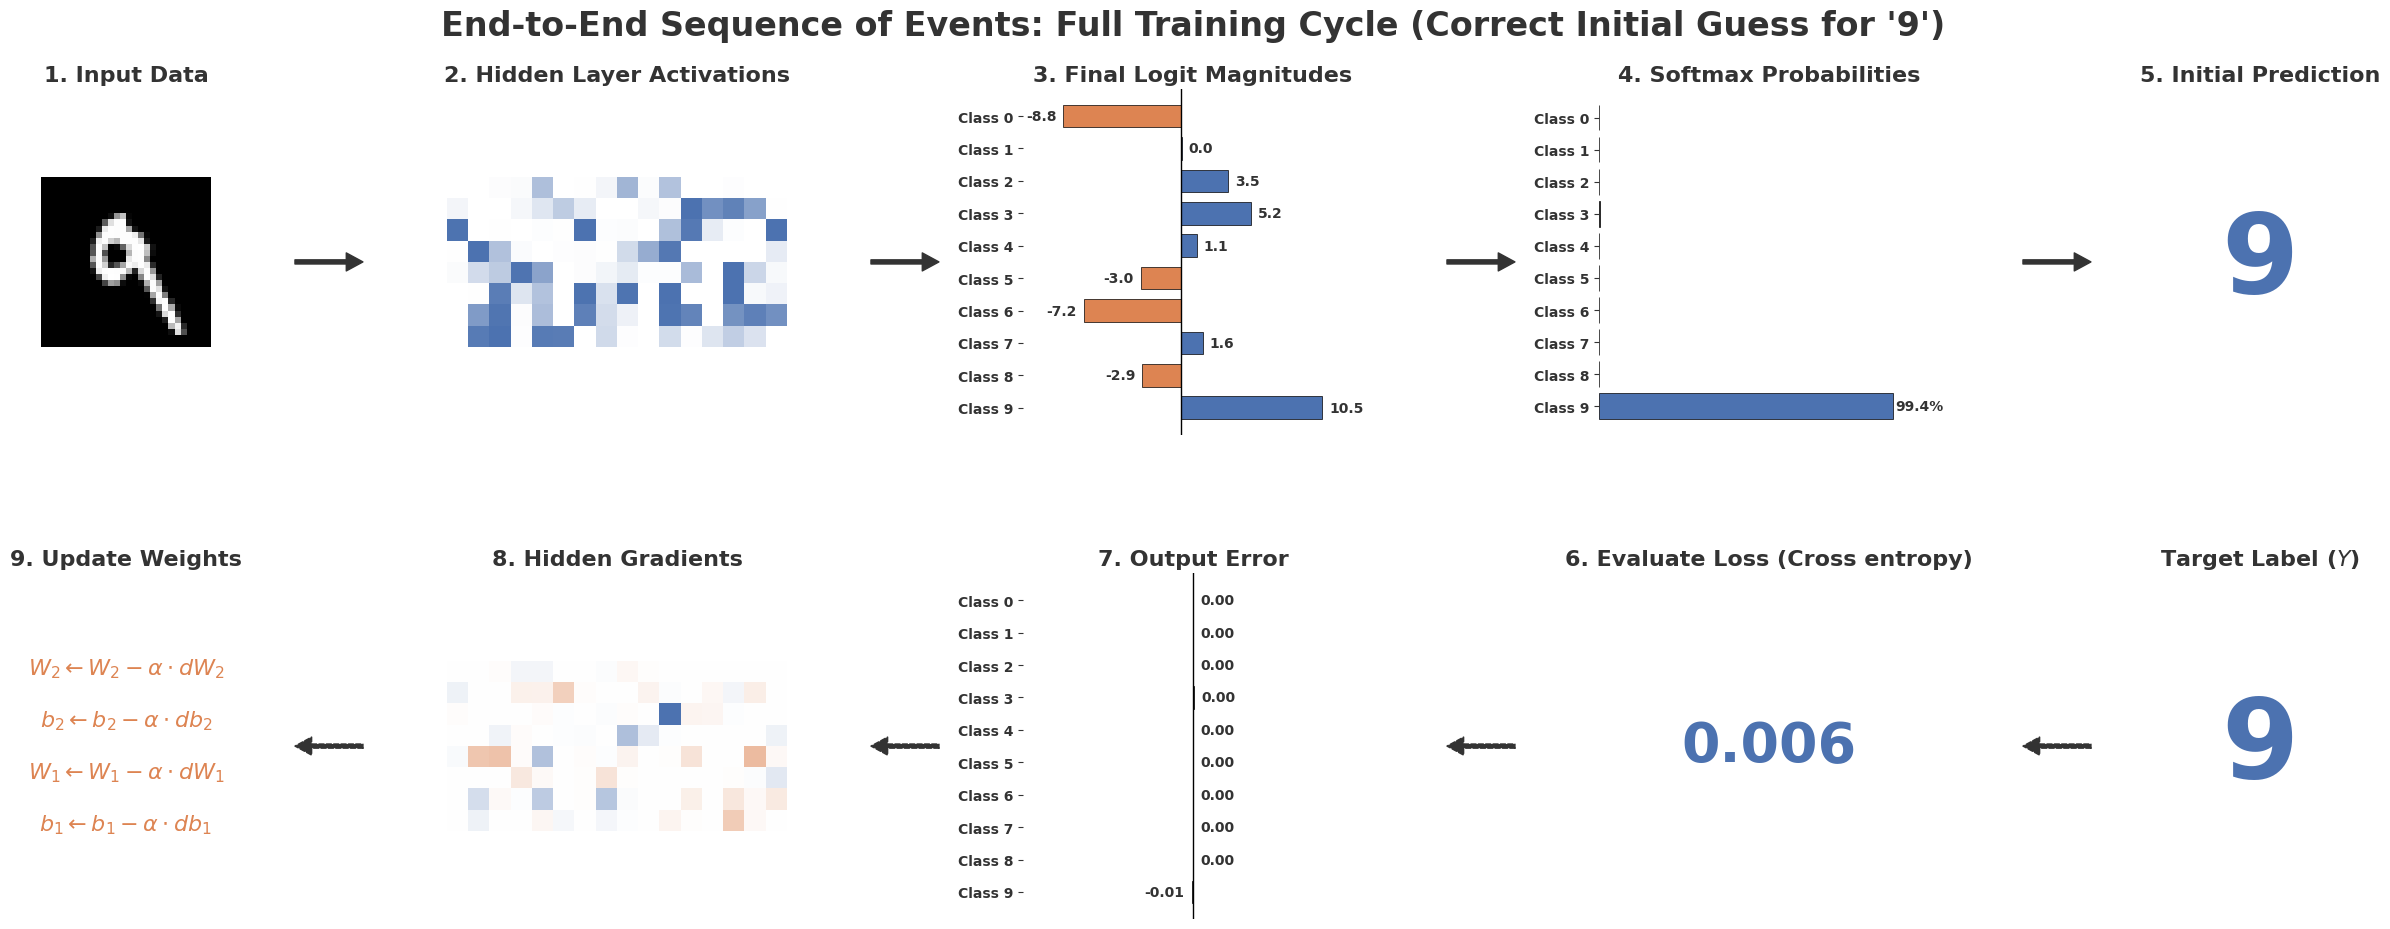

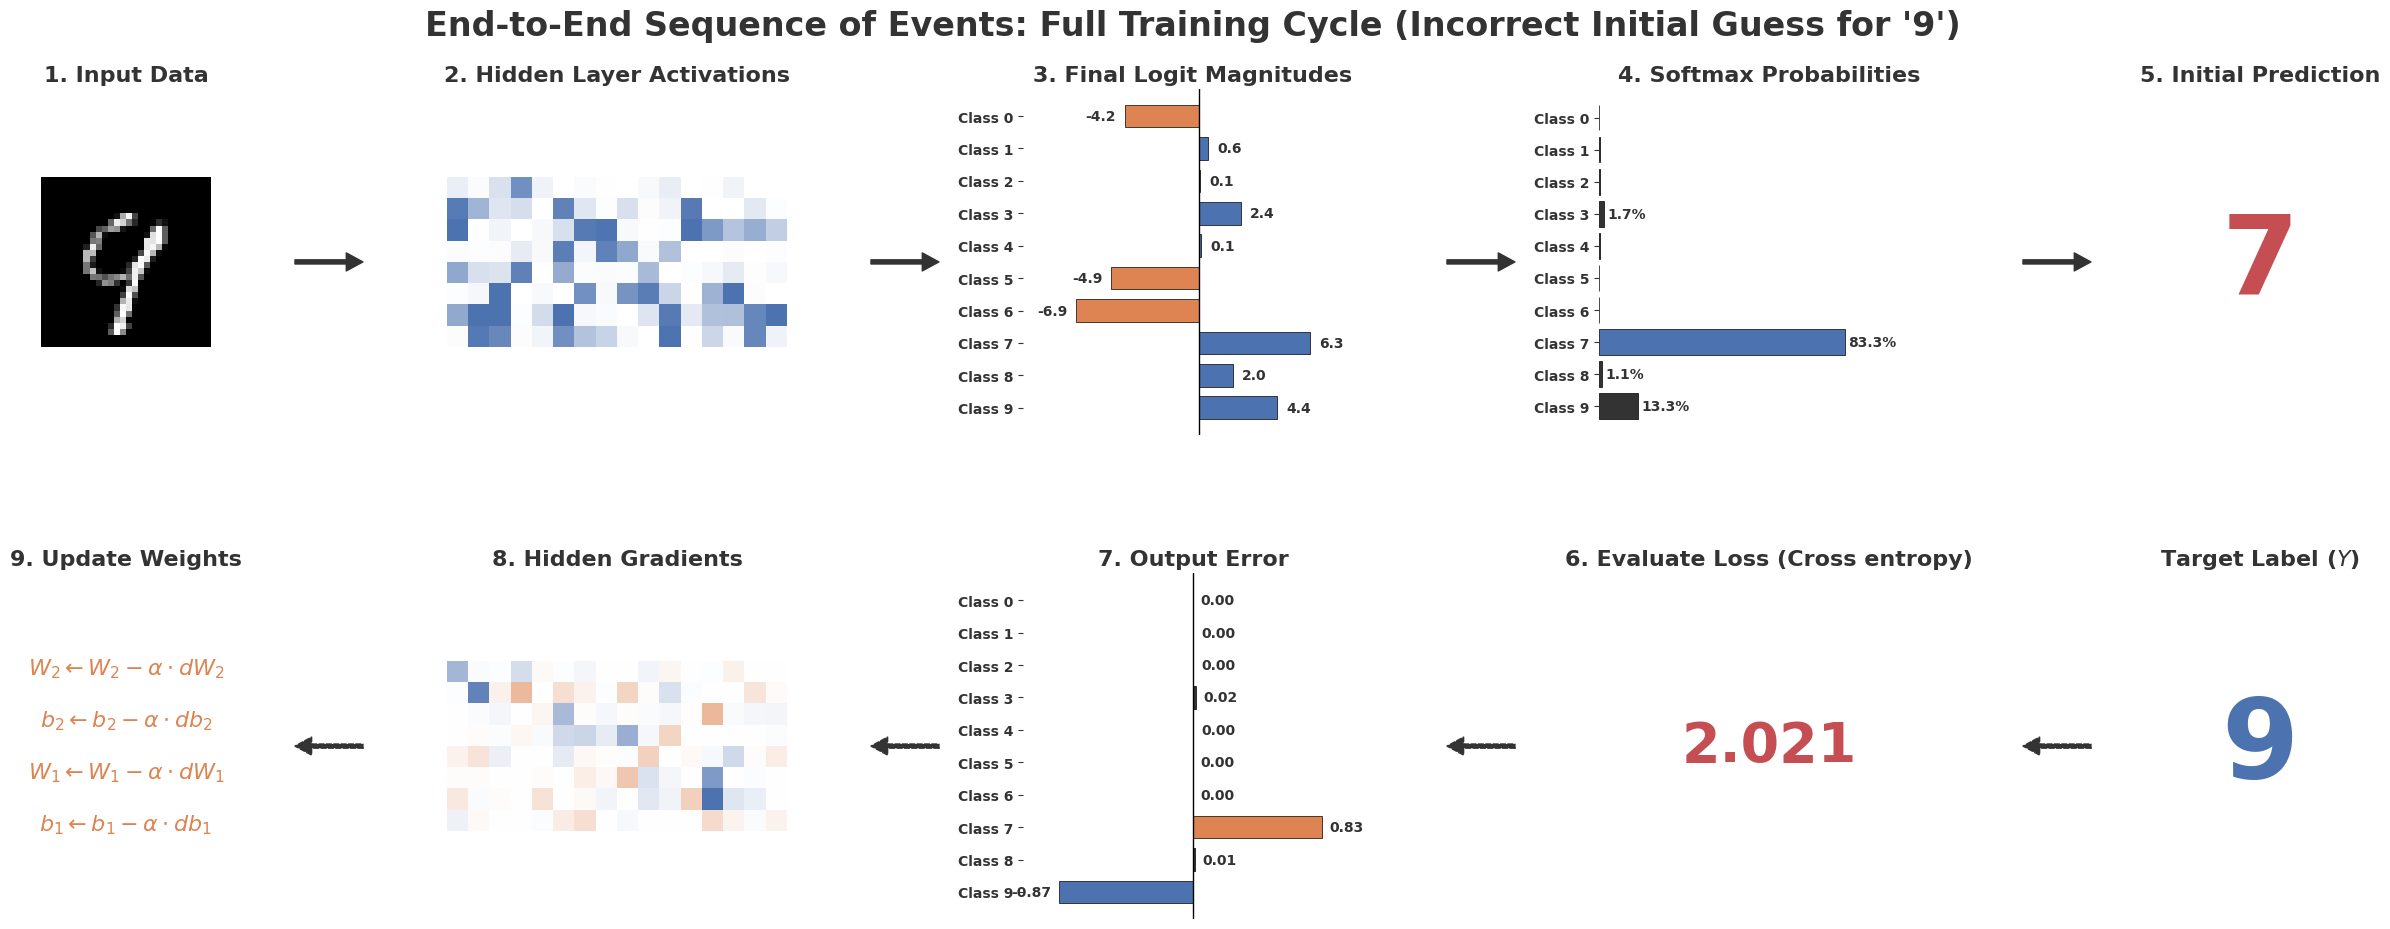

In [11]:
# 8. MLP End-to-End Architecture Overview (Forward & Backward Sequence)
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec

os.makedirs('images/MLP/overview', exist_ok=True)

# Select the target digit to profile (e.g., '9' from reference image index 4)
target_digit = reference_labels[4]

# Find a correct example (we use the reference image)
img_correct = reference_images[4]

# Find an incorrect example for the same target digit
all_preds_arr = np.array(all_preds)
all_trues_arr = np.array(all_trues)
incorrect_indices = np.where((all_trues_arr == target_digit) & (all_preds_arr != target_digit))[0]

if len(incorrect_indices) > 0:
    idx_fail = incorrect_indices[0]
    img_incorrect = test_loader.dataset[idx_fail][0].squeeze().numpy()
else:
    img_incorrect = None

examples = []
if img_correct is not None:
    examples.append(("Correct Initial Guess", img_correct, target_digit))
if img_incorrect is not None:
    examples.append(("Incorrect Initial Guess", img_incorrect, target_digit))

for status, img, true_label in examples:
    # Double the height to fit the backward pass row below
    fig = plt.figure(figsize=(24, 10))
    
    # Mathematical Forward Pass 
    x_in = img.reshape(1, 784)
    z1 = np.dot(x_in, model.w1) + model.b1
    a1 = 1 / (1 + np.exp(-z1))
    z2 = np.dot(a1, model.w2) + model.b2

    # Array Math for Softmax Layer probabilities
    exp_z2 = np.exp(z2 - np.max(z2, axis=1, keepdims=True))
    a2 = exp_z2 / np.sum(exp_z2, axis=1, keepdims=True)
    
    probs = a2.flatten()
    logits = z2.flatten()
    pred_label = np.argmax(probs)

    # Mathematical Backward Pass
    y_onehot = np.zeros(10)
    y_onehot[true_label] = 1.0
    dz2 = probs - y_onehot
    
    # Calculating back to the hidden layer gradient for visualization
    da1 = np.dot(dz2, model.w2.T).flatten()
    dz1 = da1 * (a1.flatten() * (1 - a1.flatten()))
    
    loss = -np.log(probs[true_label] + 1e-10)
    
    # Compute actual parameter gradients to simulate "what happens next"
    dw2 = np.dot(a1.T, dz2.reshape(1, -1))
    db2 = dz2
    dw1 = np.dot(x_in.T, dz1.reshape(1, -1))
    db1 = dz1
    
    title_suffix = f"({status} for '{true_label}')"
    # Adjusted y-position for the title so it fits beautifully in the saved bounding box
    fig.suptitle(f'End-to-End Sequence of Events: Full Training Cycle {title_suffix}', fontsize=24, fontweight='bold', y=0.96)

    # 2 rows layout: Top row for Forward Pass, Bottom row for Training/Backward Pass. Using hspace instead of tight_layout
    gs = gridspec.GridSpec(2, 9, width_ratios=[1.0, 0.5, 2.0, 0.5, 2.0, 0.5, 2.0, 0.5, 1.0], height_ratios=[1, 1], hspace=0.4)

    # ==============================================================================================
    # ROW 0: THE FORWARD PASS (INFERENCE)
    # ==============================================================================================

    # --- PANEL 1: Input (X) ---
    ax0_t = fig.add_subplot(gs[0, 0]); ax0_t.axis('off')
    ax0_t.set_title('1. Input Data', fontsize=16, fontweight='bold', color=COLOR_TEXT)
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img, cmap='gray')
    ax0.set_xticks([])
    ax0.set_yticks([])
    for spine in ax0.spines.values(): spine.set_visible(False)

    # Arrow 1 ->
    ax1 = fig.add_subplot(gs[0, 1]); ax1.axis('off')
    ax1.annotate('', xy=(0.9, 0.5), xytext=(0.1, 0.5), xycoords='axes fraction', arrowprops=dict(facecolor=COLOR_TEXT, edgecolor=COLOR_TEXT, width=3, headwidth=13))

    # --- PANEL 2: Hidden Layer (A1) ---
    ax2_t = fig.add_subplot(gs[0, 2]); ax2_t.axis('off')
    ax2_t.set_title('2. Hidden Layer Activations', fontsize=16, fontweight='bold', color=COLOR_TEXT)
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.imshow(a1.reshape(8, 16), cmap=CMAP_SEQUENTIAL, interpolation='nearest')
    ax2.axis('off')

    # Arrow 2 ->
    ax3 = fig.add_subplot(gs[0, 3]); ax3.axis('off')
    ax3.annotate('', xy=(0.9, 0.5), xytext=(0.1, 0.5), xycoords='axes fraction', arrowprops=dict(facecolor=COLOR_TEXT, edgecolor=COLOR_TEXT, width=3, headwidth=13))

    # --- PANEL 3: Raw Logits (Z2) ---
    ax4_t = fig.add_subplot(gs[0, 4]); ax4_t.axis('off')
    ax4_t.set_title('3. Final Logit Magnitudes', fontsize=16, fontweight='bold', color=COLOR_TEXT)
    ax4 = fig.add_subplot(gs[0, 4])
    classes = np.arange(10)
    colors = [COLOR_PRIMARY if val > 0 else COLOR_SECONDARY for val in logits]
    bars_logits = ax4.barh(classes, logits, color=colors, height=0.7, edgecolor='black', linewidth=0.5)
    
    ax4.axvline(0, color='black', linewidth=1)
    ax4.set_yticks(classes)
    ax4.set_yticklabels([f"Class {i}" for i in classes], fontweight='bold')
    ax4.invert_yaxis()

    for bar, val in zip(bars_logits, logits):
        if val >= 0:
            ax4.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', ha='left', fontsize=10, fontweight='bold')
        else:
            ax4.text(val - 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', ha='right', fontsize=10, fontweight='bold')

    ax4.set_xlim(min(logits) - 3, max(logits) + 3)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.spines['bottom'].set_visible(False)
    ax4.spines['left'].set_visible(False)
    ax4.set_xticks([])

    # Arrow 3 ->
    ax5 = fig.add_subplot(gs[0, 5]); ax5.axis('off')
    ax5.annotate('', xy=(0.9, 0.5), xytext=(0.1, 0.5), xycoords='axes fraction', arrowprops=dict(facecolor=COLOR_TEXT, edgecolor=COLOR_TEXT, width=3, headwidth=13))

    # --- PANEL 4: Softmax Probabilities (A2) ---
    ax6_t = fig.add_subplot(gs[0, 6]); ax6_t.axis('off')
    ax6_t.set_title('4. Softmax Probabilities', fontsize=16, fontweight='bold', color=COLOR_TEXT)
    ax6 = fig.add_subplot(gs[0, 6])
    prob_colors = [COLOR_PRIMARY if i == pred_label else COLOR_TEXT for i in classes]
    bars_probs = ax6.barh(classes, probs * 100, color=prob_colors, edgecolor='black', linewidth=0.5)

    ax6.set_yticks(classes)
    ax6.set_yticklabels([f"Class {i}" for i in classes], fontweight='bold')
    ax6.invert_yaxis()
    
    for spine in ax6.spines.values(): spine.set_visible(False)
    ax6.set_xticks([])

    for bar, p in zip(bars_probs, probs):
        if p * 100 > 1.0: # Only text labels for things visibly likely
            ax6.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{p*100:.1f}%', va='center', ha='left', fontsize=10, fontweight='bold')
    ax6.set_xlim(0, 115) 

    # Arrow 4 ->
    ax7 = fig.add_subplot(gs[0, 7]); ax7.axis('off')
    ax7.annotate('', xy=(0.9, 0.5), xytext=(0.1, 0.5), xycoords='axes fraction', arrowprops=dict(facecolor=COLOR_TEXT, edgecolor=COLOR_TEXT, width=3, headwidth=13))

    # --- PANEL 5: Final Prediction (Y) ---
    ax8_t = fig.add_subplot(gs[0, 8]); ax8_t.axis('off')
    # Clarify that this is the PRE-UPDATE choice
    ax8_t.set_title('5. Initial Prediction', fontsize=16, fontweight='bold', color=COLOR_TEXT)
    ax8 = fig.add_subplot(gs[0, 8])
    pred_c = COLOR_PRIMARY if pred_label == true_label else COLOR_ERROR
    ax8.text(0.5, 0.5, str(pred_label), fontsize=80, fontweight='bold', color=pred_c, ha='center', va='center')
    ax8.axis('off')

    # ==============================================================================================
    # ROW 1: THE BACKWARD PASS (TRAINING / CORRECTION)
    # Flows Right-to-Left
    # ==============================================================================================

    # --- PANEL 6: True Target (Col 8) ---
    ax16_t = fig.add_subplot(gs[1, 8]); ax16_t.axis('off')
    ax16_t.set_title('Target Label ($Y$)', fontsize=16, fontweight='bold', color=COLOR_TEXT)
    ax16 = fig.add_subplot(gs[1, 8])
    ax16.text(0.5, 0.5, str(true_label), fontsize=80, fontweight='bold', color=COLOR_PRIMARY, ha='center', va='center')
    ax16.axis('off')

    # Arrow 5 <-
    ax15 = fig.add_subplot(gs[1, 7]); ax15.axis('off')
    ax15.annotate('', xy=(0.1, 0.5), xytext=(0.9, 0.5), xycoords='axes fraction', arrowprops=dict(facecolor=COLOR_TEXT, edgecolor=COLOR_TEXT, width=3, headwidth=13, linestyle='--'))

    # --- PANEL 7: Loss Evaluation (Col 6) ---
    ax14_t = fig.add_subplot(gs[1, 6]); ax14_t.axis('off')
    ax14_t.set_title('6. Evaluate Loss (Cross entropy)', fontsize=16, fontweight='bold', color=COLOR_TEXT)
    ax14 = fig.add_subplot(gs[1, 6])
    loss_c = COLOR_PRIMARY if pred_label == true_label else COLOR_ERROR
    ax14.text(0.5, 0.5, f'{loss:.3f}', fontsize=40, fontweight='bold', color=loss_c, ha='center', va='center')
    ax14.axis('off')

    # Arrow 6 <-
    ax13 = fig.add_subplot(gs[1, 5]); ax13.axis('off')
    ax13.annotate('', xy=(0.1, 0.5), xytext=(0.9, 0.5), xycoords='axes fraction', arrowprops=dict(facecolor=COLOR_TEXT, edgecolor=COLOR_TEXT, width=3, headwidth=13, linestyle='--'))

    # --- PANEL 8: Output Error dZ2 (Col 4) ---
    ax12_t = fig.add_subplot(gs[1, 4]); ax12_t.axis('off')
    ax12_t.set_title('7. Output Error', fontsize=16, fontweight='bold', color=COLOR_TEXT)
    ax12 = fig.add_subplot(gs[1, 4])
    # Positive error implies predicted probability was too high (needs to go down)
    dz2_colors = [COLOR_SECONDARY if val > 0.05 else (COLOR_PRIMARY if val < -0.05 else COLOR_TEXT) for val in dz2]
    bars_dz2 = ax12.barh(classes, dz2, color=dz2_colors, height=0.7, edgecolor='black', linewidth=0.5)
    
    ax12.axvline(0, color='black', linewidth=1)
    ax12.set_yticks(classes)
    ax12.set_yticklabels([f"Class {i}" for i in classes], fontweight='bold')
    ax12.invert_yaxis()

    for bar, val in zip(bars_dz2, dz2):
        if val >= 0:
            ax12.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', ha='left', fontsize=10, fontweight='bold')
        else:
            ax12.text(val - 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', ha='right', fontsize=10, fontweight='bold')

    ax12.set_xlim(-1.1, 1.1)
    for spine in ax12.spines.values(): spine.set_visible(False)
    ax12.set_xticks([])

    # Arrow 7 <-
    ax11 = fig.add_subplot(gs[1, 3]); ax11.axis('off')
    ax11.annotate('', xy=(0.1, 0.5), xytext=(0.9, 0.5), xycoords='axes fraction', arrowprops=dict(facecolor=COLOR_TEXT, edgecolor=COLOR_TEXT, width=3, headwidth=13, linestyle='--'))

    # --- PANEL 9: Hidden Error dZ1 (Col 2) ---
    ax10_t = fig.add_subplot(gs[1, 2]); ax10_t.axis('off')
    ax10_t.set_title('8. Hidden Gradients', fontsize=16, fontweight='bold', color=COLOR_TEXT)
    ax10 = fig.add_subplot(gs[1, 2])
    v_max = max(abs(dz1.min()), abs(dz1.max())) + 1e-6
    ax10.imshow(dz1.reshape(8, 16), cmap=CMAP_DIVERGING, interpolation='nearest', vmin=-v_max, vmax=v_max)
    ax10.axis('off')

    # Arrow 8 <-
    ax9 = fig.add_subplot(gs[1, 1]); ax9.axis('off')
    ax9.annotate('', xy=(0.1, 0.5), xytext=(0.9, 0.5), xycoords='axes fraction', arrowprops=dict(facecolor=COLOR_TEXT, edgecolor=COLOR_TEXT, width=3, headwidth=13, linestyle='--'))

    # --- PANEL 10: Param Updating (Col 0) ---
    ax8_bt_t = fig.add_subplot(gs[1, 0]); ax8_bt_t.axis('off')
    ax8_bt_t.set_title('9. Update Weights', fontsize=16, fontweight='bold', color=COLOR_TEXT)
    
    # We no longer plot new probabilities. We just show the weight update logic.
    ax8_bt = fig.add_subplot(gs[1, 0])
    
    formulas = [
        r'$W_2 \leftarrow W_2 - \alpha \cdot dW_2$',
        r'$b_2 \leftarrow b_2 - \alpha \cdot db_2$',
        r'$W_1 \leftarrow W_1 - \alpha \cdot dW_1$',
        r'$b_1 \leftarrow b_1 - \alpha \cdot db_1$'
    ]
    for i, formula in enumerate(formulas):
        ax8_bt.text(0.5, 0.725 - (i * 0.15), formula, fontsize=16, ha='center', va='center', fontweight='bold', color=COLOR_SECONDARY)
        
    ax8_bt.axis('off')
    
    # Clean up the grid boundaries and plot
    fig.subplots_adjust(top=0.88, bottom=0.05, left=0.02, right=0.98, hspace=0.4, wspace=0.4)
    
    status_suffix = "failed" if "Incorrect" in status else "correct"
    filename = f"mlp_training_flowchart_{status_suffix}_guess.png"
    plt.savefig(f'images/MLP/overview/{filename}', dpi=300, bbox_inches='tight')
    plt.show()


--- Training with 16 hidden neurons ---
The number of training data: 60000
The number of testing data: 10000
Hidden Size 16, Epoch 1/30, Test Acc: 0.8090
Hidden Size 16, Epoch 2/30, Test Acc: 0.8915
Hidden Size 16, Epoch 3/30, Test Acc: 0.9051
Hidden Size 16, Epoch 4/30, Test Acc: 0.9128
Hidden Size 16, Epoch 5/30, Test Acc: 0.9163
Hidden Size 16, Epoch 6/30, Test Acc: 0.9188
Hidden Size 16, Epoch 7/30, Test Acc: 0.9218
Hidden Size 16, Epoch 8/30, Test Acc: 0.9224
Hidden Size 16, Epoch 9/30, Test Acc: 0.9266
Hidden Size 16, Epoch 10/30, Test Acc: 0.9277
Hidden Size 16, Epoch 11/30, Test Acc: 0.9280
Hidden Size 16, Epoch 12/30, Test Acc: 0.9307
Hidden Size 16, Epoch 13/30, Test Acc: 0.9296
Hidden Size 16, Epoch 14/30, Test Acc: 0.9294
Hidden Size 16, Epoch 15/30, Test Acc: 0.9345
Hidden Size 16, Epoch 16/30, Test Acc: 0.9332
Hidden Size 16, Epoch 17/30, Test Acc: 0.9352
Hidden Size 16, Epoch 18/30, Test Acc: 0.9336
Hidden Size 16, Epoch 19/30, Test Acc: 0.9342
Hidden Size 16, Epoch 20/

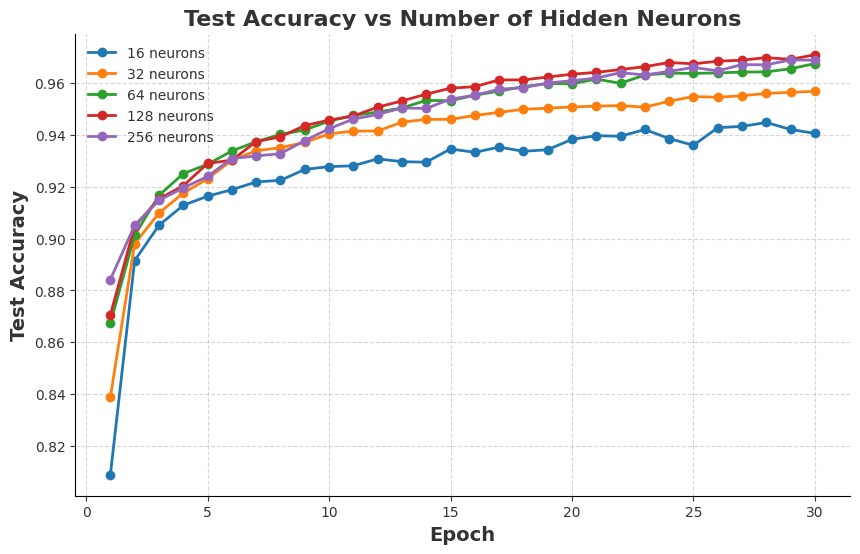

In [12]:
# 9. Benchmark: Test Accuracy vs Number of Hidden Neurons
from MLP_template import evaluate

def train_and_evaluate(hidden_size, epochs=30, lr=0.1):
    input_size = 784
    output_size = 10
    
    loader_train, loader_test = load_data()
    model_bench = MLP(input_size, hidden_size, output_size, lr)
    
    test_acc_history_bench = []
    
    for epoch in range(epochs):
        for inputs, labels in loader_train:
            x = inputs.view(-1, input_size).numpy()
            y = labels.numpy()
            model_bench.train(x, y)
            
        test_acc = evaluate(model_bench, loader_test, input_size)
        test_acc_history_bench.append(test_acc)
        print(f"Hidden Size {hidden_size}, Epoch {epoch+1}/{epochs}, Test Acc: {test_acc:.4f}")
        
    return test_acc_history_bench

hidden_sizes = [16, 32, 64, 128, 256]
results = {}

for size in hidden_sizes:
    print(f"\n--- Training with {size} hidden neurons ---")
    history = train_and_evaluate(size, epochs=30)
    results[size] = history

# Plot the results
plt.figure(figsize=(10, 6))
for size, history in results.items():
    plt.plot(range(1, len(history) + 1), history, marker='o', label=f'{size} neurons', linewidth=2)

plt.title('Test Accuracy vs Number of Hidden Neurons', fontsize=16, fontweight='bold', color=COLOR_TEXT)
plt.xlabel('Epoch', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=14, fontweight='bold')
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.5)

os.makedirs('images/MLP/curves', exist_ok=True)
plt.savefig('images/MLP/curves/neuron_comparison.png', dpi=300, bbox_inches='tight')
plt.show()